In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Retail Analytics Project")
print(f"Pandas version: {pd.__version__}")

Retail Analytics Project
Pandas version: 3.0.3


In [37]:
import pandas as pd

df = pd.read_csv("../data/raw/supermarket_sales.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [38]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [40]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [41]:
df.groupby("Product line")["Total"].sum().sort_values(ascending=False)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64

In [42]:
df["Date"] = pd.to_datetime(df["Date"])

In [43]:
df["Date"].head()

0   2019-01-05
1   2019-03-08
2   2019-03-03
3   2019-01-27
4   2019-02-08
Name: Date, dtype: datetime64[us]

In [44]:
df["Weekday"] = df["Date"].dt.day_name()

In [45]:
df[["Date", "Weekday"]].head()

,Date,Weekday
0,2019-01-05,Saturday
1,2019-03-08,Friday
2,2019-03-03,Sunday
3,2019-01-27,Sunday
4,2019-02-08,Friday


In [46]:
df["Weekday"].value_counts()

Weekday
Saturday     164
Tuesday      158
Wednesday    143
Friday       139
Thursday     138
Sunday       133
Monday       125
Name: count, dtype: int64

In [47]:
df.groupby("Weekday")["Total"].sum().sort_values(ascending=False)

Weekday
Saturday     56120.8095
Tuesday      51482.2455
Thursday     45349.2480
Sunday       44457.8925
Friday       43926.3405
Wednesday    43731.1350
Monday       37899.0780
Name: Total, dtype: float64

In [48]:
df.groupby("Weekday")["Total"].mean().sort_values(ascending=False)

Weekday
Saturday     342.200058
Sunday       334.269868
Thursday     328.617739
Tuesday      325.836997
Friday       316.016838
Wednesday    305.812133
Monday       303.192624
Name: Total, dtype: float64

In [49]:
df["Time"].head()

0    13:08
1    10:29
2    13:23
3    20:33
4    10:37
Name: Time, dtype: str

In [50]:
df["Time"] = pd.to_datetime(df["Time"])
df["Hour"] = df["Time"].dt.hour
df[["Time", "Hour"]].head()

C:\Users\yarch\AppData\Local\Temp\ipykernel_19836\2467937422.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"])


,Time,Hour
0,2026-06-12 13:08:00,13
1,2026-06-12 10:29:00,10
2,2026-06-12 13:23:00,13
3,2026-06-12 20:33:00,20
4,2026-06-12 10:37:00,10


In [51]:
df["Hour"].value_counts().sort_index()

Hour
10    101
11     90
12     89
13    103
14     83
15    102
16     77
17     74
18     93
19    113
20     75
Name: count, dtype: int64

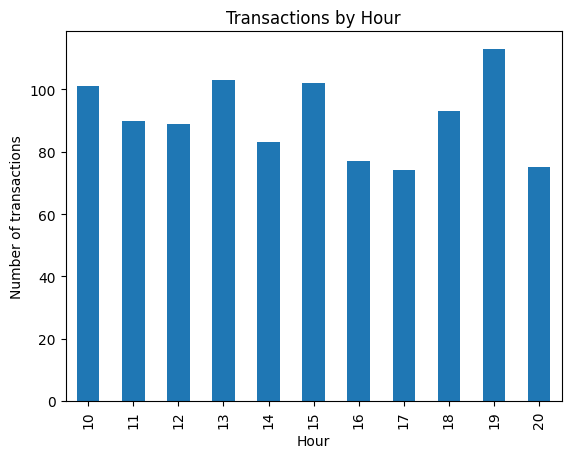

In [52]:
transactions_by_hour = df["Hour"].value_counts().sort_index()

transactions_by_hour.plot(kind="bar")
plt.title("Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of transactions")
plt.show()

In [53]:
df.groupby(["Weekday", "Hour"]).size()

Weekday    Hour
Friday     10      18
           11      11
           12      10
           13      16
           14      14
                   ..
Wednesday  16      10
           17      10
           18      17
           19      14
           20       9
Length: 77, dtype: int64

In [54]:
weekday_order =[
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

df["Weekday"] = pd.Categorical(
    df["Weekday"],
    categories=weekday_order,
    ordered=True
)

In [55]:
df.groupby(["Weekday", "Hour"]).size().unstack(fill_value=0)

Hour,10,11,12,13,14,15,16,17,18,19,20
Weekday,,,,,,,,,,,
Monday,12,9,14,10,6,18,16,11,11,8,10
Tuesday,16,20,11,13,15,14,9,9,12,28,11
Wednesday,10,12,14,20,10,17,10,10,17,14,9
Thursday,18,15,11,12,14,12,12,15,9,10,10
Friday,18,11,10,16,14,18,10,6,11,13,12
Saturday,16,12,18,14,11,12,14,12,18,23,14
Sunday,11,11,11,18,13,11,6,11,15,17,9


In [56]:
df.groupby("Product line").agg({
    "Total": ["sum", "mean"],
    "Quantity": "sum"
}).round(2)

Total         Quantity
                             sum    mean      sum
Product line                                     
Electronic accessories  54337.53  319.63      971
Fashion accessories     54305.90  305.09      902
Food and beverages      56144.84  322.67      952
Health and beauty       49193.74  323.64      854
Home and lifestyle      53861.91  336.64      911
Sports and travel       55122.83  332.07      920

In [57]:
product_summary = (
    df.groupby("Product line")
    .agg(
        Revenue=("Total", "sum"),
        Avg_Transactions=("Total", "mean"),
        Quantity_Sold=("Quantity", "sum")
    )
    .round(2)
)

product_summary.sort_values("Revenue", ascending=False)

,Revenue,Avg_Transactions,Quantity_Sold
Product line,,,
Food and beverages,56144.84,322.67,952
Sports and travel,55122.83,332.07,920
Electronic accessories,54337.53,319.63,971
Fashion accessories,54305.90,305.09,902
Home and lifestyle,53861.91,336.64,911
Health and beauty,49193.74,323.64,854


In [58]:
df.groupby("Product line")["Quantity"].mean().sort_values(ascending=False)

Product line
Electronic accessories    5.711765
Home and lifestyle        5.693750
Health and beauty         5.618421
Sports and travel         5.542169
Food and beverages        5.471264
Fashion accessories       5.067416
Name: Quantity, dtype: float64

In [59]:
df["Product line"].value_counts()

Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

In [60]:
df.groupby("Product line")["Unit price"].mean().sort_values(ascending=False)

Product line
Fashion accessories       57.153652
Sports and travel         56.993253
Food and beverages        56.008851
Home and lifestyle        55.316937
Health and beauty         54.854474
Electronic accessories    53.551588
Name: Unit price, dtype: float64

In [61]:
df.groupby(["Weekday", "Product line"])["Total"] \
.sum() \
.unstack() \
.round(2)

Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Weekday,,,,,,
Monday,5922.13,6419.52,6612.23,8448.24,6095.34,4401.62
Tuesday,10110.92,7423.28,9848.30,8559.59,7708.73,7831.42
Wednesday,4864.91,6819.78,11188.48,5888.75,6474.81,8494.40
Thursday,12435.16,7725.89,6798.59,5582.47,5427.30,7379.83
Friday,4848.15,9554.76,4558.43,8331.02,6875.42,9758.56
Saturday,9744.38,10778.92,9375.40,7410.34,9208.01,9603.76
Sunday,6411.88,5583.74,7763.42,4973.34,12072.29,7653.23


In [62]:
df.columns.tolist()

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Total',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating',
 'Weekday',
 'Hour']

In [63]:
df.groupby("Customer type")["Total"].sum()

Customer type
Member    164223.444
Normal    158743.305
Name: Total, dtype: float64

In [64]:
df.groupby("Customer type")["Invoice ID"].count()

Customer type
Member    501
Normal    499
Name: Invoice ID, dtype: int64

In [65]:
df.groupby("Customer type")["Total"].mean()

Customer type
Member    327.791305
Normal    318.122856
Name: Total, dtype: float64

In [66]:
df.groupby("Branch")["Total"].sum().sort_values(ascending=False)

Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64

In [67]:
df.groupby("Branch")["Rating"].mean()

Branch
A    7.027059
B    6.818072
C    7.072866
Name: Rating, dtype: float64

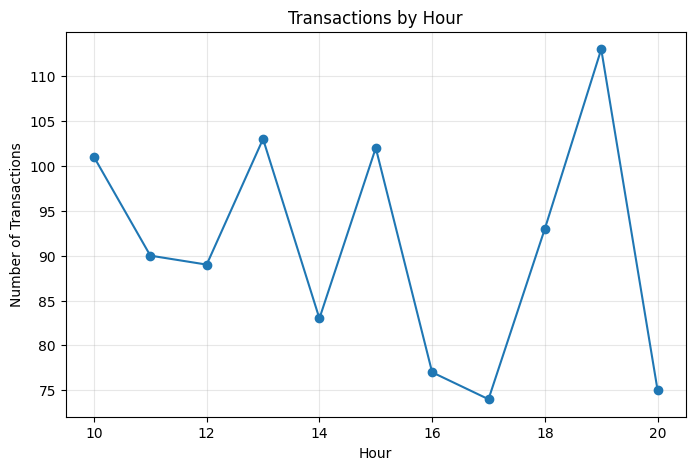

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    transactions_by_hour.index,
    transactions_by_hour.values,
    marker="o"
)

plt.title("Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.grid(alpha=0.3)

plt.show()

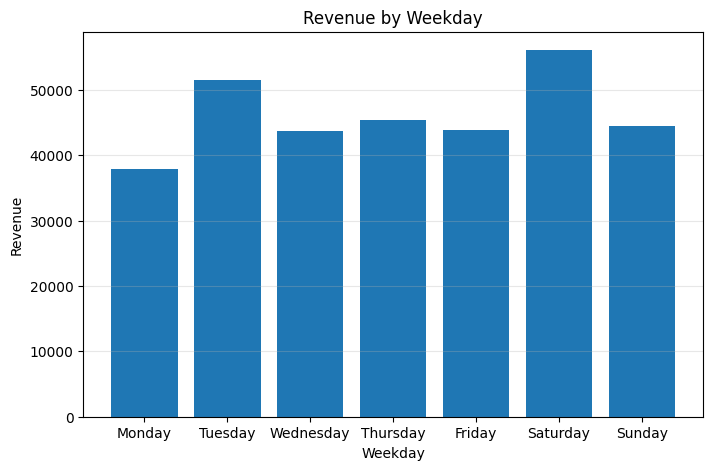

In [69]:
weekday_revenue = df.groupby("Weekday")["Total"].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(weekday_revenue.index, weekday_revenue.values)

plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.grid(axis="y", alpha=0.3)

plt.show()

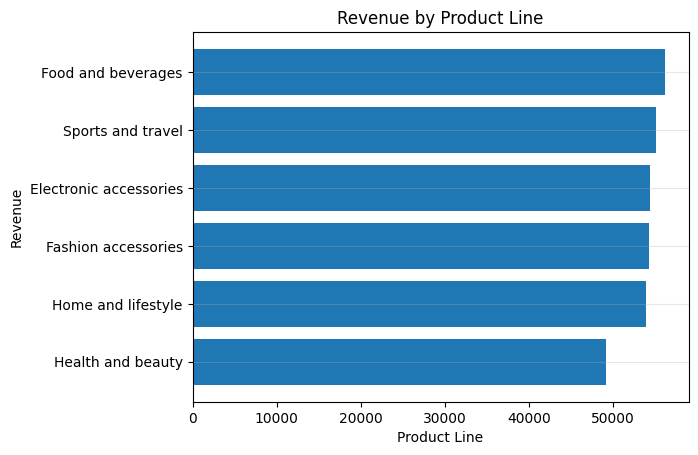

In [70]:
import matplotlib.pyplot as plt

product_revenue = df.groupby("Product line")["Total"].sum().sort_values(ascending=False)

plt.barh(product_revenue.index, product_revenue.values)

plt.gca().invert_yaxis()

plt.title("Revenue by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Revenue")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Key Findings

## Sales Patterns

- Saturday generated the highest revenue, with Tuesday ranking second.
- Monday generates the least revenue.
- Rest of the days perform on par with each other.
- 19:00 was the busiest hour, recording the highest number of transactions.
- There is a sharp dip in customer visits around 16 hour.

## Product Performance

- Revenue from all the product lines is almost balanced.
- Food and Beverages generated the highest revenue, while Health and Beauty generated the lowest.

## Customer Analysis

- Members generate slightly higher revenue than Normal customers.
- Number of transactions across Members and Normal customers is identical.
- Basket value of Members is only a little more than Normal Customers.

## Branch Analysis

- Branch C generated the highest revenue, but the difference compared to the other branches was only around 4%.
- Ratings are balanced across branches.